# Isfahan intersection traffic: graph mining and time-series analysis

## tl;dr

- The raw archive contains **5,454,089 intersection records** across **75 intersections** from October 2018 to January 2021.
- Among the same 41 trusted intersections in February and March 2020, median volume fell **-25.8%**; among 43 paired intersections, April to May rebounded **24.4%**. These are descriptive associations, not causal estimates.
- At intersection **1081**, north and south approaches carry **68.9%** of measured entries. It ranks **61/74** by volume but **5/74** by functional-similarity centrality.
- The weekly-profile graph has **4 communities** and remains connected; DTW favors **2 daily-shape clusters** (silhouette 0.57).
- November 2020 is absent and December 2020 is partial, so neither is used as a complete month in headline comparisons.

## Context & Methods

The numbered SCATS boxes are lane-detector channels on approaches to the stop line. The analysis therefore calls them **approach entries** rather than exits. `0` remains a valid count; `2046`, `2047`, and `NA` are unavailable readings. Coverage normalization is applied only when at least half of the operational detector set is present.

### Key Assumptions

- Timestamps are interpreted in Isfahan local civil time.
- Traffic volume is the sum across operational channels; normalization scales only for unavailable channels, not for missing time intervals.
- Citywide level charts use trusted intersection-months; month-to-month changes use paired intersections.
- The functional graph encodes similarity of 168-bin weekly profiles. Its edges do not imply a road connection or vehicle transfer.
- 2019 is the only complete pre-pandemic year and supplies the common-panel month-of-year comparison.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
TABLES = PROJECT_ROOT / 'outputs' / 'tables'
FIGURES = PROJECT_ROOT / 'outputs' / 'figures'
summary = json.loads((TABLES / 'analysis_summary.json').read_text(encoding='utf-8'))
summary['data_window']

{'first_month': '2018-10',
 'last_month': '2021-01',
 'raw_intersection_records': 5454089,
 'intersections_with_raw_data': 75,
 'trusted_intersection_months': 1433,
 'partial_source_months': ['2020-12'],
 'missing_source_months': ['2020-11']}

## Data

The compact source-month audit makes missing and partial coverage explicit.

In [2]:
source_quality = pd.read_csv(TABLES / 'source_month_quality.csv')
source_quality[['source_month', 'source_temporal_coverage', 'intersection_records', 'records_with_normalized_volume']].tail(8)

,source_month,source_temporal_coverage,intersection_records,records_with_normalized_volume
19,2020-05,0.988911,214839,152447
20,2020-06,0.999653,210167,151501
21,2020-07,0.999328,217102,153292
22,2020-08,0.998320,216883,150582
23,2020-09,0.978472,206006,144054
24,2020-10,1.000000,217248,152172
25,2020-12,0.202957,43428,29332
26,2021-01,0.989247,216220,154549


## Results

### The strongest network-wide discontinuity is March 2020

The level plot uses the median intersection and an interquartile band. The paired-intersection result is the safer percentage comparison because detector availability changes over time.

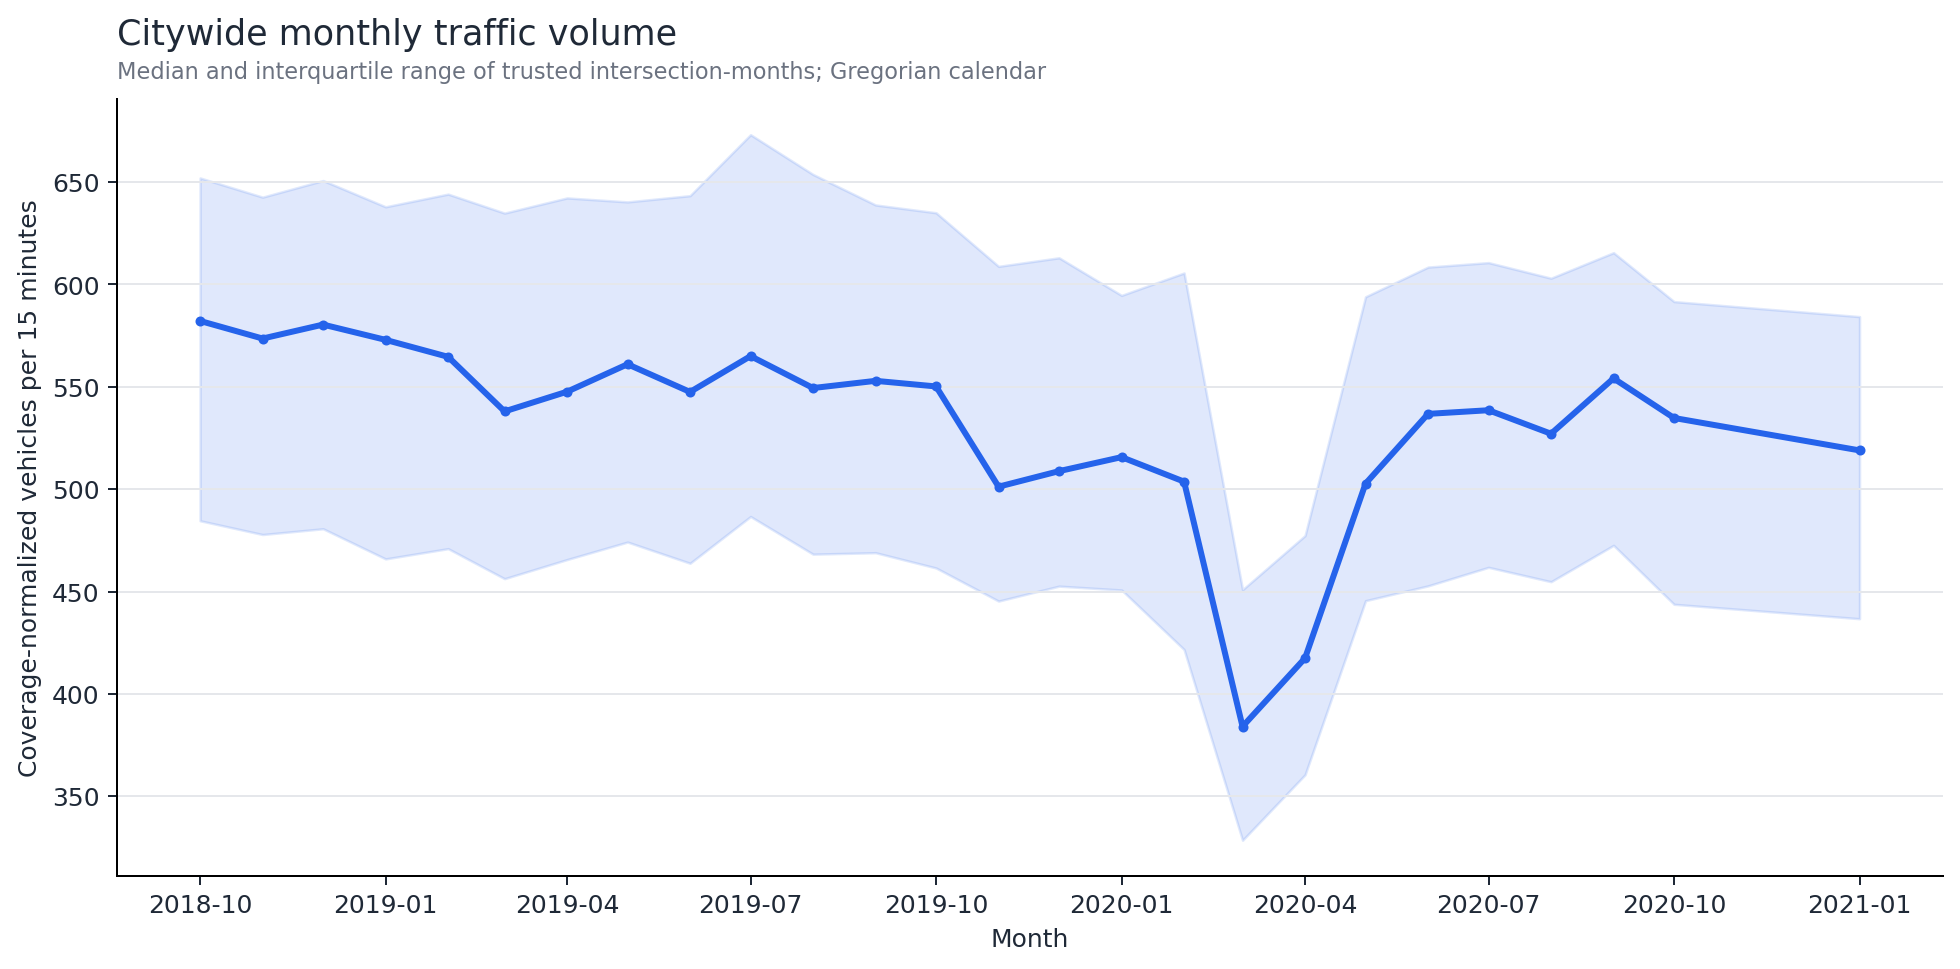

In [3]:
display(Image(filename=str(FIGURES / 'city_monthly_volume.png'), width=980))

In [4]:
paired = pd.read_csv(TABLES / 'paired_month_changes.csv')
paired.sort_values('median_change').head(6)

,year_month,previous_month,paired_intersections,median_change,mean_change,p25_change,p75_change
16,2020-03,2020-02,41,-0.258425,-0.257639,-0.303212,-0.231676
23,2020-10,2020-09,46,-0.053327,-0.048226,-0.066734,-0.037407
12,2019-11,2019-10,42,-0.027270,-0.031692,-0.054532,-0.015552
4,2019-03,2019-02,65,-0.022306,-0.020502,-0.034241,-0.007866
9,2019-08,2019-07,64,-0.020535,-0.021881,-0.028581,-0.010980
10,2019-09,2019-08,65,-0.015704,-0.003043,-0.028549,-0.000748


### Seasonal variation is modest in the 2019 common panel

The peak-to-trough spread is much smaller than the March 2020 discontinuity, indicating that ordinary Gregorian month seasonality is a secondary driver in this archive.

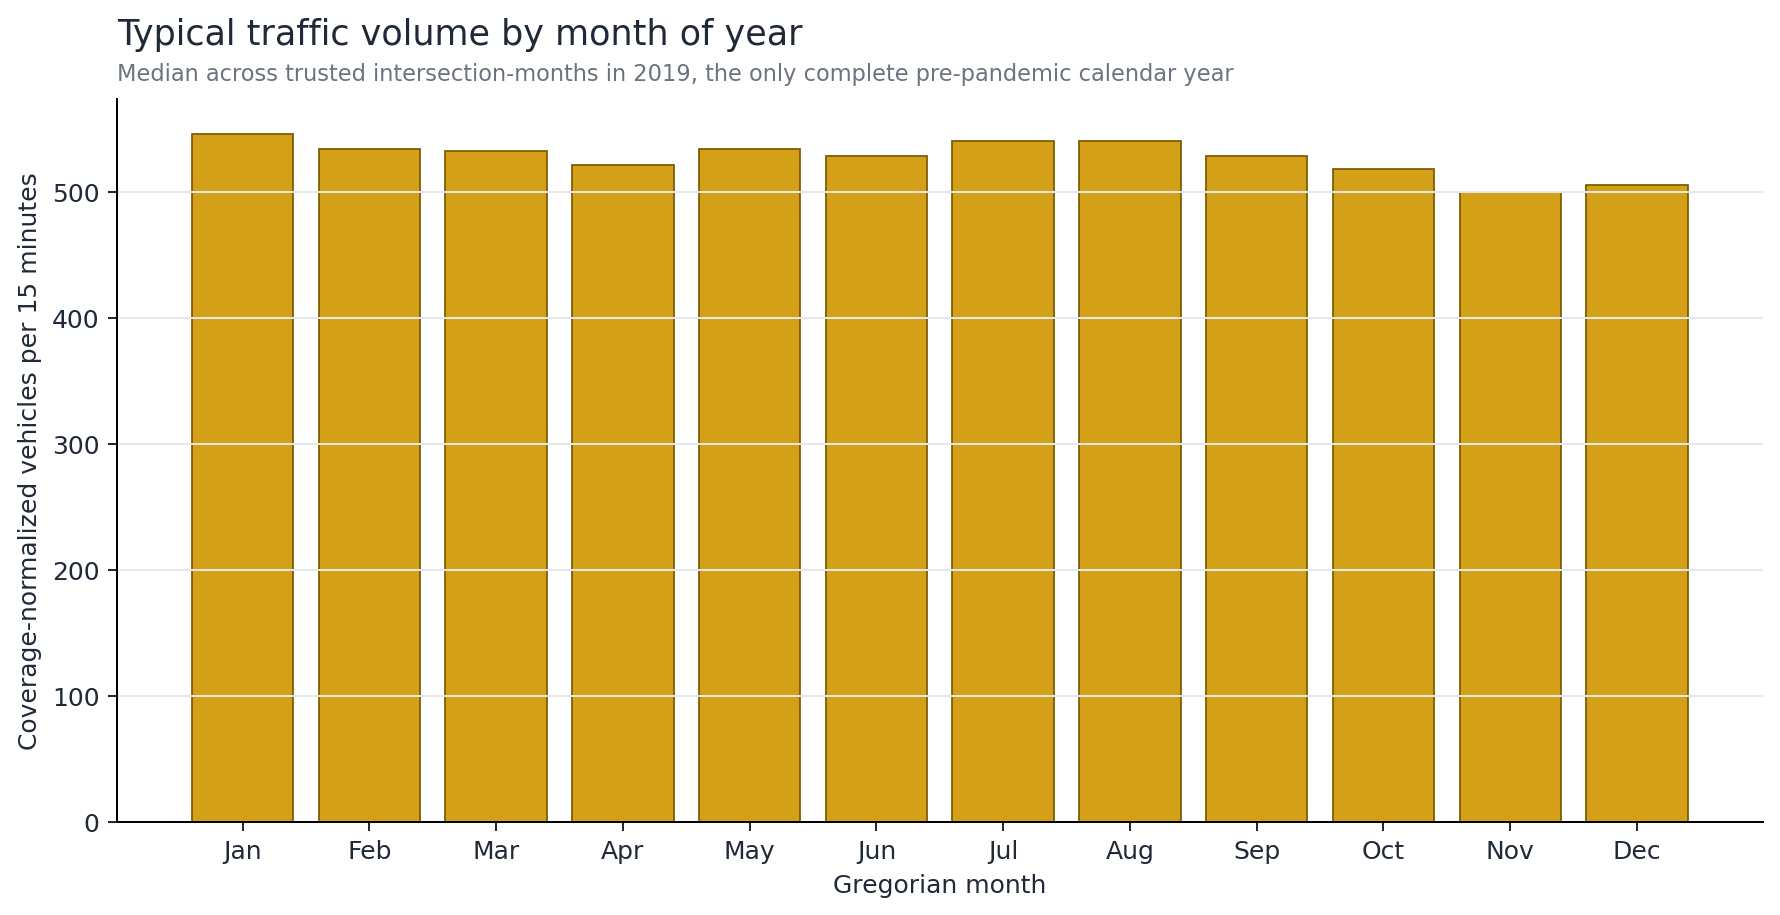

In [5]:
display(Image(filename=str(FIGURES / 'month_of_year_pattern.png'), width=920))

### 1081 is a north–south-oriented site with a pronounced Friday pattern

The approach split is stable outside the early-2020 discontinuity. The weekday profile shows Friday materially below most other days during daytime hours.

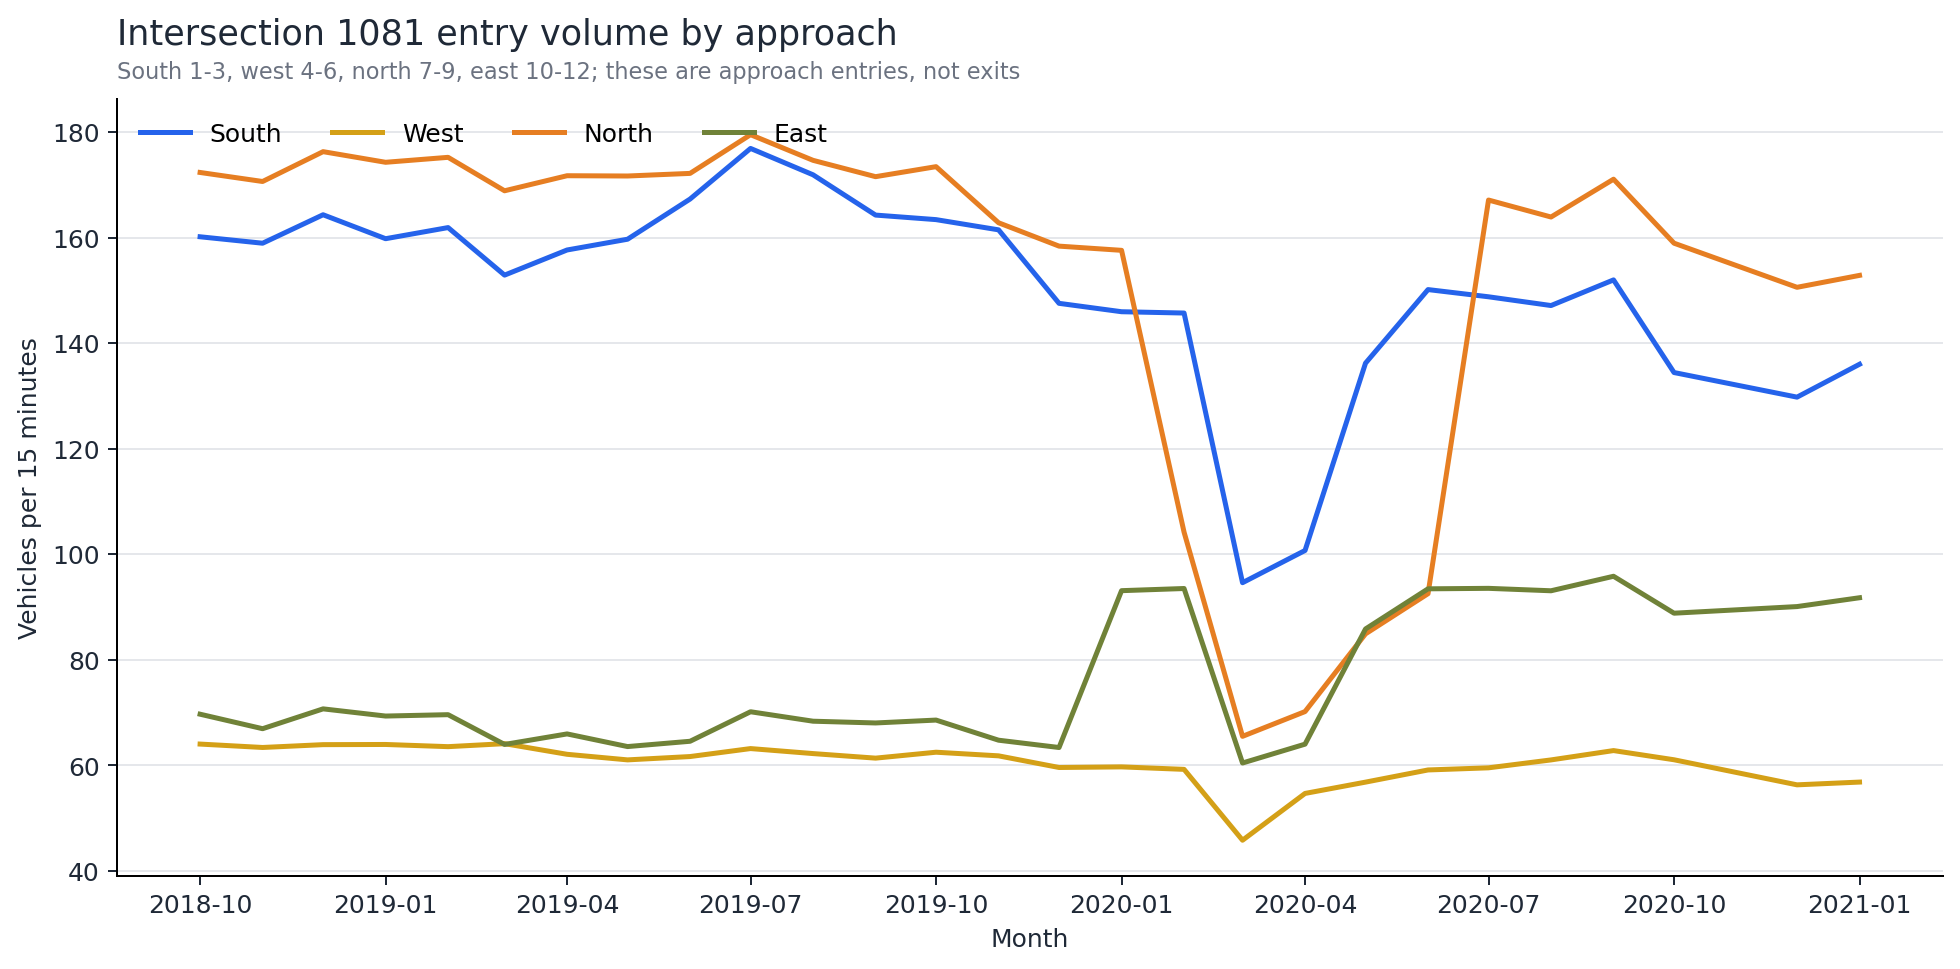

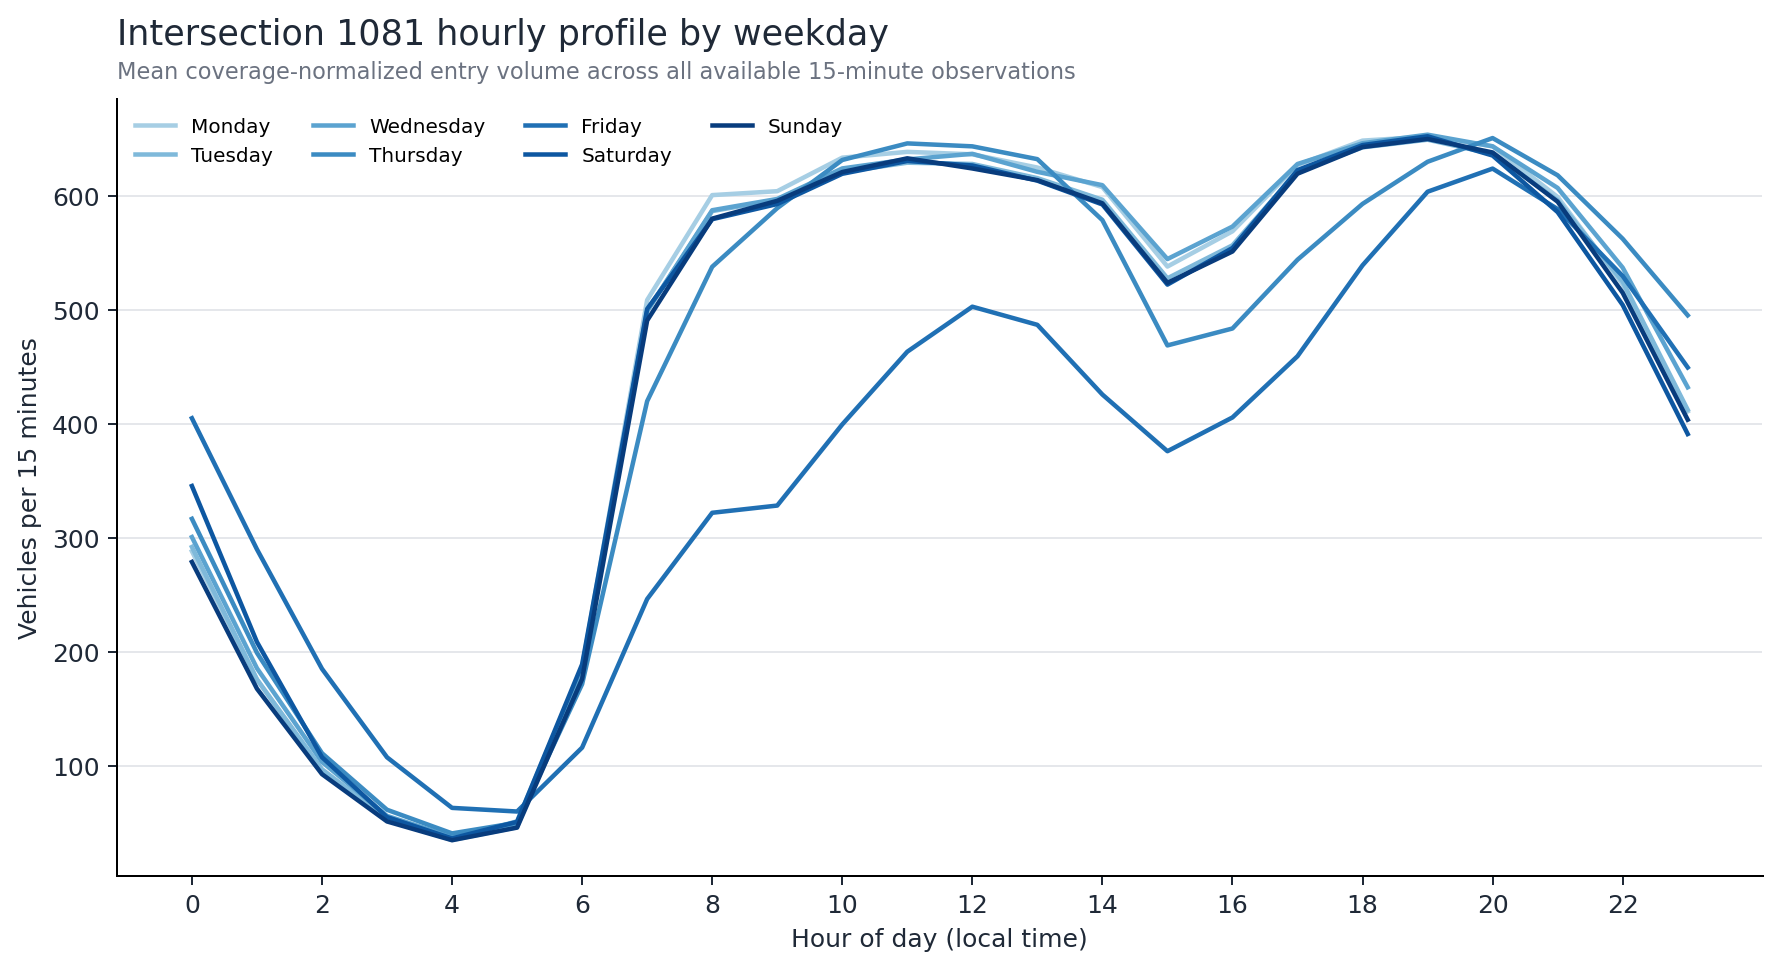

In [6]:
display(Image(filename=str(FIGURES / 'intersection_1081_approaches.png'), width=980))
display(Image(filename=str(FIGURES / 'intersection_1081_hourly_weekday.png'), width=920))

### Functional communities reveal recurring operating shapes

Nodes with many strong similarity edges are representative of common network behavior, not necessarily the busiest or geographically central intersections.

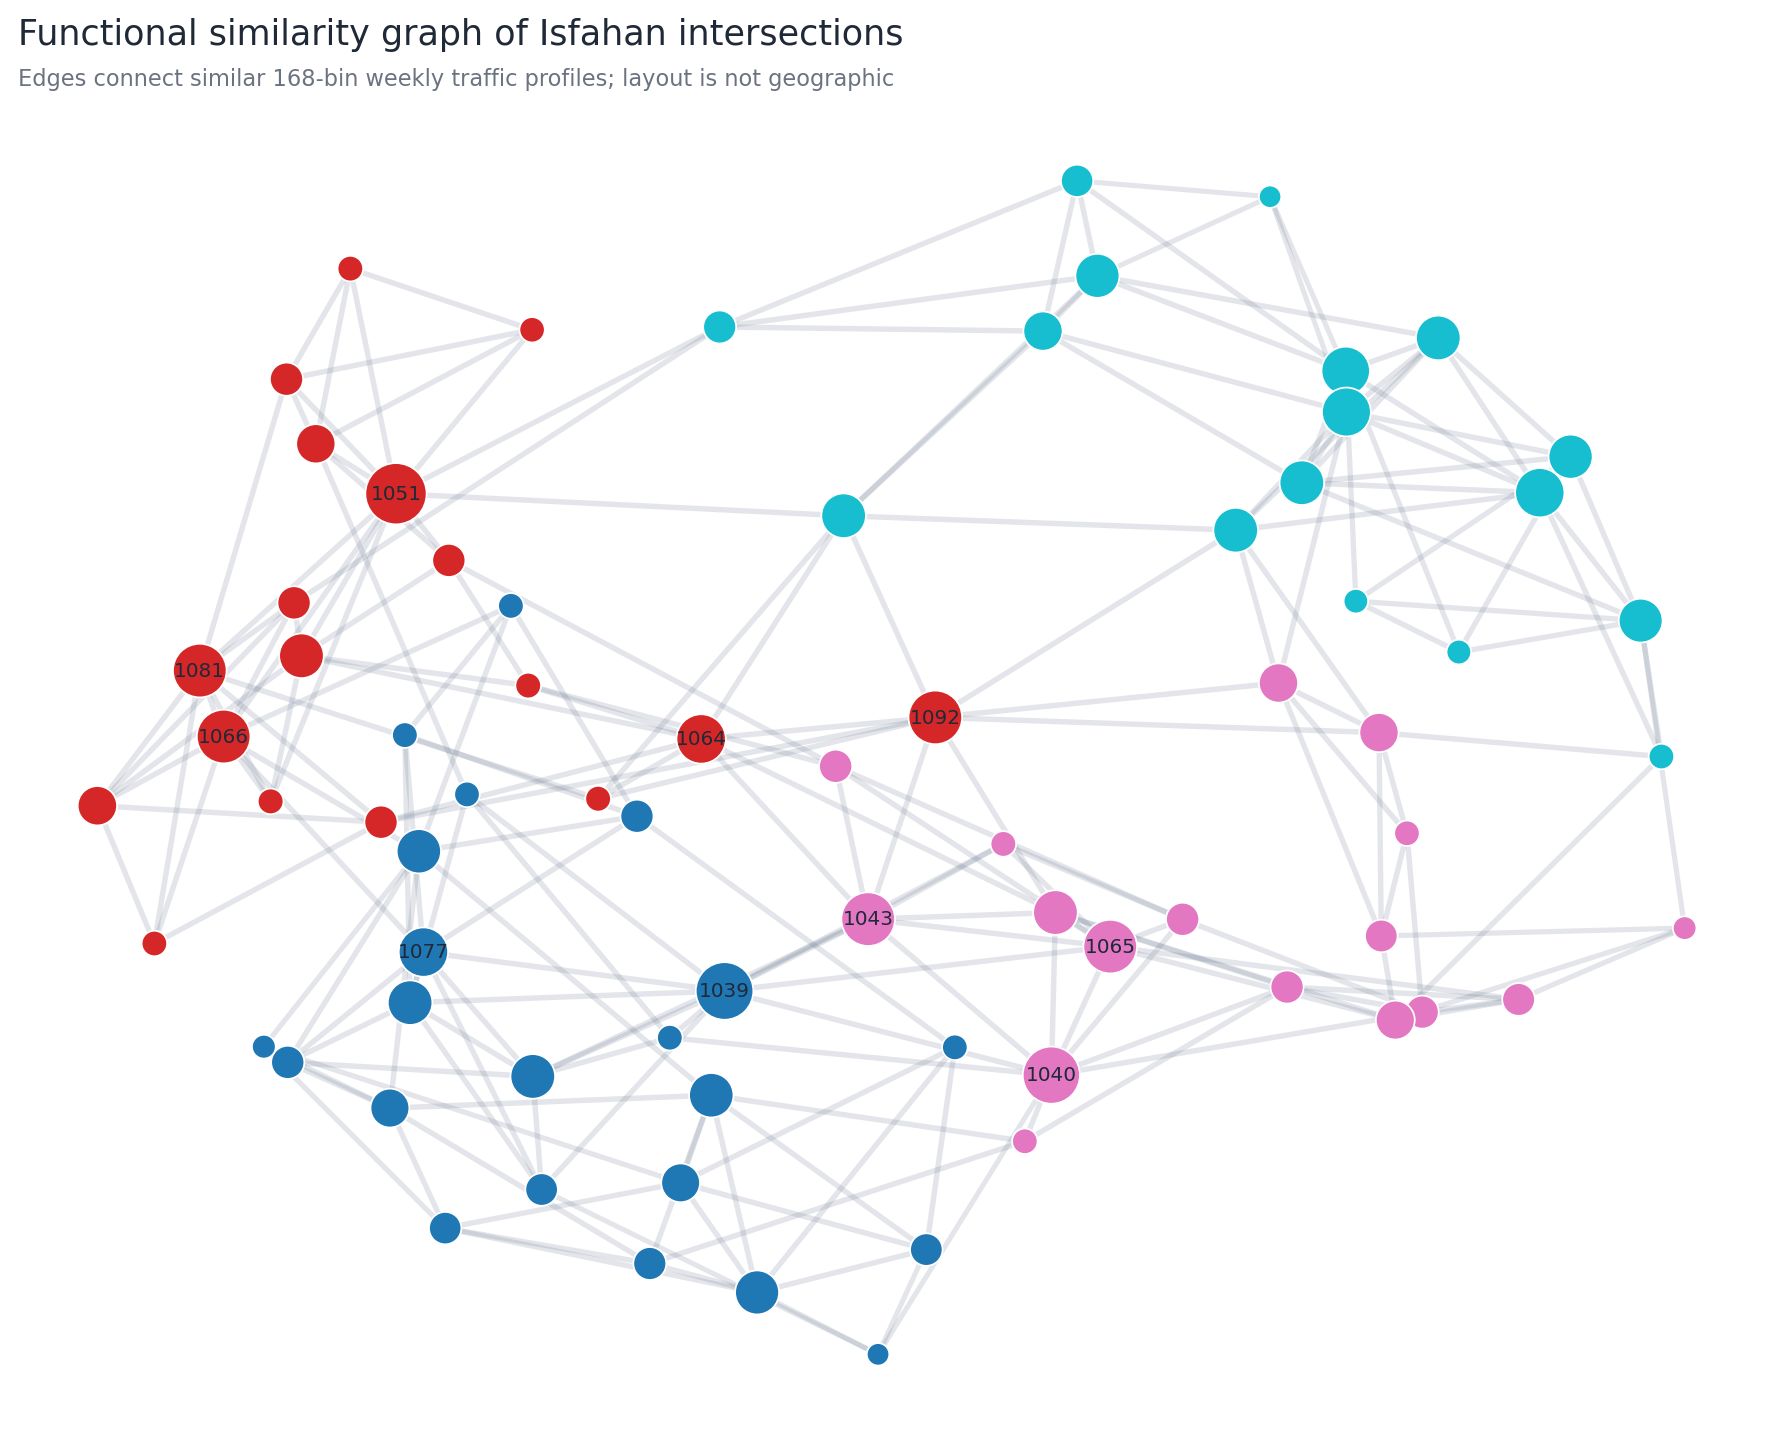

In [7]:
display(Image(filename=str(FIGURES / 'functional_similarity_graph.png'), width=900))

In [8]:
nodes = pd.read_csv(TABLES / 'functional_graph_nodes.csv', encoding='utf-8-sig')
nodes.sort_values('weighted_degree', ascending=False)[['intersection_id', 'community', 'dtw_cluster', 'weighted_degree', 'mean_volume']].head(12)

,intersection_id,community,dtw_cluster,weighted_degree,mean_volume
29,1051,2,2,10.924336,366.802161
21,1039,1,2,9.942495,518.838466
22,1040,3,2,9.842980,591.806493
25,1043,3,2,8.964847,1416.256759
50,1081,2,2,8.959751,441.289811
58,1092,2,2,8.958668,731.467518
37,1066,2,2,8.955365,538.360691
36,1065,3,2,8.952356,441.751955
35,1064,2,2,7.973770,372.635363
46,1077,1,2,7.957751,464.443330


## Limitations, uncertainty, and robustness checks

- The archive contains a high unavailable-reading rate, and the trusted panel shrinks in late 2019. Headline changes therefore use within-intersection pairs.
- November 2020 is missing; December 2020 covers only about one fifth of the month.
- Geocoded coordinates are review candidates from OpenStreetMap/Nominatim, not municipal GIS truth.
- The two-cluster DTW solution isolates a small outlier group; community results are more granular and should be used for operational segmentation.
- Entry/exit conservation cannot be tested without a verified downstream intersection/link mapping.

## Takeaways

1. Use the paired March decline and May rebound as the primary time-series event, with no causal label unless external policy/incident data are added.
2. Treat 1081 as a useful representative monitoring site: it is low-volume but highly connected in behavior space, with a stable north–south orientation.
3. Operationalize the four functional communities for peer baselines and anomaly detection; do not compare every intersection against one citywide average.
4. Verify coordinates and road adjacency in QGIS/municipal GIS before building a physical directed road graph.
5. Add holiday, Nowruz, Ramadan, weather, and traffic-control-event data before interpreting seasonal or causal mechanisms.